## Scrape wiki, dblp

In [ ]:
import re
import string
import requests
import pandas as pd
from bs4 import BeautifulSoup


# Function to retrieve information for a scientist from a specific URL
def get_scientist_info(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')

    # Extract the full name
    name = re.sub(r'\([^)]*\)', '', soup.find('span', class_='mw-page-title-main').text.strip())

    # Extract the surname
    surname = name.split()[-1]

    # Find the scientist's information table
    infobox = soup.find('table', class_='infobox biography vcard')

    # Extract the number of awards
    awards = 0
    awards_section = soup.find('span', string=lambda text: text and 'awards' in text.lower())

    if infobox and infobox.find('th', string='Awards'):
        awards_header = infobox.find('th', string='Awards')
        awards_row = awards_header.find_parent('tr')
        awards_cell = awards_row.find('td')
        if awards_cell.find_all('li'):
            awards = len(awards_cell.find_all('li'))
        else:
            awards = len(awards_cell.find_all('a', attrs={'title': True}))
    elif awards_section:
        awards_list = awards_section.find_next('ul').find_all('li')
        awards += len(awards_list)

    # Extract education text
    education = ''
    education_section = soup.find('span', string=lambda text: text and 'education' in text.lower(), attrs={'id': True})
    if education_section:
        education_list = []
        sibling = education_section.find_next()
        while sibling and sibling.name not in ['h2', 'h3']:
            if sibling.name == 'p':
                education_list.append(sibling.text.strip())
            sibling = sibling.find_next()
        education = ' '.join(education_list)
        print(education)
    return name, surname, awards, education


# Function to count DBLP publications
def count_dblp_publications(name):
    search_name = '+'.join(name.split())
    search_url = f'https://dblp.org/search/author?q={search_name}'
    print("Searching DBLP records for", name, "...")
    response = requests.get(search_url)
    if response.status_code != 200:
        print("Failed to retrieve search results for", name)
        return 0

    soup = BeautifulSoup(response.content, 'html.parser')
    publ_section = soup.find('div', id='publ-section')
    if not publ_section:
        print("Publication section not found for", name)
        return 0

    entries = publ_section.find_all('li', class_='entry')
    print(len(entries), "publications found for", name, "!")
    return len(entries)


# Function to retrieve all scientist URLs from Wikipedia
def get_urls():
    url = "https://en.wikipedia.org/wiki/List_of_computer_scientists"
    response = requests.get(url)
    soup = BeautifulSoup(response.content, "html.parser")
    span_tags = soup.find_all("span", string=lambda text: text and text in list(string.ascii_uppercase))

    href_list = []
    for span in span_tags:
        ul_parent = span.find_next("ul")
        if ul_parent:
            list_items = ul_parent.find_all("li")
            for item in list_items:
                anchor = item.find_next("a")
                if anchor:
                    href = 'https://en.wikipedia.org' + anchor.get("href")
                    href_list.append(href)

    return href_list


if __name__ == '__main__':
    print("Extracting URLs...", end=' ')
    scientists = get_urls()
    print("[done]")

    data_for_df = []
    print("Extracting scientists' info...", end=' ')
    for scientist_url in scientists:
        name, surname, awards, education = get_scientist_info(scientist_url)
        publications = count_dblp_publications(name)

        if education:
            data_for_df.append([surname, awards, education, publications])
            print(surname,awards,education,publications)
    print("[done]")

    df = pd.DataFrame(data_for_df, columns=['surname', 'awards', 'education', 'publications'])
    df[['surname', 'awards', 'education', 'publications']].to_csv('scientists_data.csv', index=False)

    print("CSV file created successfully!")


Extracting URLs... [done]
Extracting scientists' info... Khan was a Bright Sparks scholar and received his PhD degree in Computer Science from University of Malaya.[14] He received his master's degree and bachelor's degree (with honors) in Computer Science from COMSATS University under COMSATS scholarship. He has also attended a summer camp on Advance Wireless Networks at Technische Universität Ilmenau under DAAD scholarship.
Searching DBLP records for Atta ur Rehman Khan ...
60 publications found for Atta ur Rehman Khan !
Khan 10 Khan was a Bright Sparks scholar and received his PhD degree in Computer Science from University of Malaya.[14] He received his master's degree and bachelor's degree (with honors) in Computer Science from COMSATS University under COMSATS scholarship. He has also attended a summer camp on Advance Wireless Networks at Technische Universität Ilmenau under DAAD scholarship. 60
Born in Eersel, Netherlands, van der Aalst received an MSc in computing science in 1988

##KDTree

In [2]:
import pandas as pd
from scipy.spatial import KDTree
import numpy as np


def name_to_ascii_sum(name):
    return sum(ord(char) for char in name)


file_path = "scientists.csv"
data = pd.read_csv(file_path)
data = data.dropna()
data = data[data['publications'] != 0]
data['Name'] = data['surname'].apply(lambda name: name.split()[-1])

# Preprocess the data
data['NameValue'] = data['Name'].apply(name_to_ascii_sum)
data['Awards'] = data['awards'].astype(int)
data['Publications'] = data['publications'].astype(int)

kd_tree_data = data[['NameValue', 'Awards', 'Publications']].values
kd_tree = KDTree(kd_tree_data)

def query_scientists(name_start, name_end, min_awards, pub_min, pub_max):
    name_start_val = name_to_ascii_sum(name_start)
    name_end_val = name_to_ascii_sum(name_end)

    # Formulate the query range using a large number instead of infinity for the upper bound of awards
    large_number = 1e9
    query_range_min = np.array([name_start_val, min_awards, pub_min])
    query_range_max = np.array([name_end_val, large_number, pub_max])

    # Calculate the midpoint and radius for the query
    midpoint = (query_range_min + query_range_max) / 2
    radius = np.sqrt(np.sum(np.square(query_range_max - query_range_min)) / 4)

    indices = kd_tree.query_ball_point(midpoint, radius)

    result = data.iloc[indices]
    return result.loc[
    (result['publications'] >= pub_min) & (result['publications'] <= pub_max),
    ['surname', 'awards', 'publications', 'education']]



## Vectorize the education

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(data['education'])


## LSH

In [4]:
!pip install datasketch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 2.5 MB/s eta 0:00:00


In [5]:
from datasketch import MinHashLSHForest, MinHash

# Number of permutations for MinHash
num_perm = 128

# MinHash objects for each scientist's education
minhashes = {}
for idx, text in enumerate(data['education']):
    m = MinHash(num_perm=num_perm)
    for word in text.split():
        m.update(word.encode('utf8'))
    minhashes[idx] = m

# Create an LSH Forest
forest = MinHashLSHForest(num_perm=num_perm)

# Add MinHash objects to the Forest
for idx, minhash in minhashes.items():
    forest.add(idx, minhash)

# Index the Forest
forest.index()


In [7]:
# Tokenize the 'Education' field and convert each document into a set of words
data['educationSet'] = data['education'].apply(lambda text: set(text.lower().split()))
data['educationSet']


0      {bachelor's, received, degree, computer, spark...
1      {workshop, department, group., editorial, euro...
2      {age,, symbols, babysitter's, teachers., berke...
3      {contributed, pure, woman, harvard, national, ...
4      {varieties, 1973, group, graduated, received, ...
                             ...                        
265    {department, graduated, various, memberships:,...
266    {degrees, his, from, number, non-honorary, a, ...
267    {cover, building, zimmerman, ranked, sciences,...
268    {raised, germany,, dentist, psychiatrist, grea...
269    {zuse, qualifying, prussian, braniewo, enter, ...
Name: educationSet, Length: 200, dtype: object

Jaccard Similarity

In [8]:
def jaccard_similarity(set1, set2):
    """Calculate the Jaccard Similarity between two sets."""
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    return len(intersection) / len(union)

def query_scientists_extended_with_jaccard(name_start, name_end, min_awards, pub_min, pub_max, similarity_threshold):
    preliminary_results = query_scientists(name_start, name_end, min_awards, pub_min, pub_max)
    indices = preliminary_results.index
    final_indices = []

    # Compute Jaccard similarity for the 'Education' field of the preliminary results
    for index in indices:
        education_set = data.at[index, 'educationSet']
        for other_index in data.index:
            other_education_set = data.at[other_index, 'educationSet']
            similarity = jaccard_similarity(education_set, other_education_set)
            if similarity > similarity_threshold:
                final_indices.append(other_index)

    # Remove duplicates from the final indices
    final_indices = list(set(final_indices))
    final_results = data.loc[final_indices]

    return final_results[['surname', 'awards', 'publications', 'education']]


final_result = query_scientists_extended_with_jaccard('A', 'G', 4, 100, 1000, 0.5)
print(final_result[final_result['surname'].str.upper().str[0].between('A', 'G')])

#print(final_result[(final_result['surname'].str.upper().str[0].between('A', 'G')) & (final_result['awards'] > 4)])



       surname  awards  publications  \
45       Croft       8           455   
54    Dongarra      15           985   
67       Foley       6           109   
88  Goldwasser      11           234   

                                            education  
45  Croft earned a bachelor's degree with honors i...  
54  Dongarra received a BSc degree in mathematics ...  
67  Foley was born in Pennsylvania. He attended Le...  
88  Born in New York City, Goldwasser obtained her...  


###Range Tree

In [9]:
!pip install bintrees-2.0.3-py2.py3-none-any.whl
!pip install rangetree
!pip install sortedcontainers


Processing ./bintrees-2.0.3-py2.py3-none-any.whl
ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: '/content/bintrees-2.0.3-py2.py3-none-any.whl'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for bintrees
  Running setup.py clean for bintrees
Failed to build bintrees
ERROR: Could not build wheels for bintrees, which is required to install pyproject.toml-based projects


In [10]:
from sortedcontainers import SortedDict

class MyRangeTree:
    def __init__(self):
        self._tree = SortedDict()

    def letter_normalization(self, surname):
        normalized = 0
        for char in surname[:3].upper():
            normalized = normalized * 26 + (ord(char) - ord('A'))
        return normalized

    def insert(self, surname, award, publications, data):
        key = (self.letter_normalization(surname), award, publications)
        self._tree[key] = data

    def query(self, surname_start, surname_end, min_award, min_publications):
        start_key = (self.letter_normalization(surname_start), 0, 0)
        # Adjust the end_key to ensure it covers any potential surname normalization up to and including surname_end
        end_key = (self.letter_normalization(surname_end) + 1, float('inf'), float('inf'))
        result = []
        for key in self._tree.irange(start_key, end_key, inclusive=(True, False)):
            if key[1] >= min_award and key[2] >= min_publications:
                result.append(self._tree[key])
        return result


In [11]:
import pandas as pd
df = pd.read_csv('scientists.csv')
my_range_tree = MyRangeTree()
for index, row in df.iterrows():
    my_range_tree.insert(row['surname'], row['awards'], row['publications'], row.to_dict()) # population


In [12]:
results = my_range_tree.query('Aaa', 'Gzz', 4, 100)
for result in results:
    print(result)


{'surname': 'Aaronson', 'awards': 4, 'education': "Aaronson grew up in the United States, though he spent a year in Asia when his father—a science writer turned public-relations executive—was posted to Hong Kong.[6] He enrolled in a school there that permitted him to skip ahead several years in math, but upon returning to the US, he found his education restrictive, getting bad grades and having run-ins with teachers. He enrolled in The Clarkson School, a gifted education program run by Clarkson University, which enabled Aaronson to apply for colleges while only in his freshman year of high school.[6] He was accepted into Cornell University, where he obtained his BSc in computer science in 2000,[7] and where he resided at the Telluride House.[8] He then attended the University of California, Berkeley, for his PhD, which he got in 2004 under the supervision of Umesh Vazirani.[9] Aaronson had shown ability in mathematics from an early age, teaching himself calculus at the age of 11, provo

In [13]:
import pandas as pd

filtered_df = pd.DataFrame(results)
from datasketch import MinHash

# Tokenize education text and create MinHashes
filtered_df['tokens'] = filtered_df['education'].apply(lambda x: set(x.lower().split()))

minhashes = []
for tokens in filtered_df['tokens']:
    m = MinHash(num_perm=128)
    for token in tokens:
        m.update(token.encode('utf8'))
    minhashes.append(m)


In [14]:
from datasketch import MinHashLSH
threshold = 0.4
lsh = MinHashLSH(threshold=threshold, num_perm=128)

# Insert MinHashes into the LSH
for i, mh in enumerate(minhashes):
    lsh.insert(str(i), mh)

for query_idx in range(0,4):
  similar_indices = lsh.query(minhashes[query_idx])

  for idx in similar_indices:
      idx = int(idx)
      print(f"Index: {idx}, Surname: {filtered_df.iloc[idx]['surname']}, Education: {filtered_df.iloc[idx]['education']}")


Index: 0, Surname: Aaronson, Education: Aaronson grew up in the United States, though he spent a year in Asia when his father—a science writer turned public-relations executive—was posted to Hong Kong.[6] He enrolled in a school there that permitted him to skip ahead several years in math, but upon returning to the US, he found his education restrictive, getting bad grades and having run-ins with teachers. He enrolled in The Clarkson School, a gifted education program run by Clarkson University, which enabled Aaronson to apply for colleges while only in his freshman year of high school.[6] He was accepted into Cornell University, where he obtained his BSc in computer science in 2000,[7] and where he resided at the Telluride House.[8] He then attended the University of California, Berkeley, for his PhD, which he got in 2004 under the supervision of Umesh Vazirani.[9] Aaronson had shown ability in mathematics from an early age, teaching himself calculus at the age of 11, provoked by symb

## Quad Tree

In [15]:
import pandas as pd
from datasketch import MinHash, MinHashLSH

# Define the Point class
class Point:
    def __init__(self, x, y, data=None):
        self.x = x
        self.y = y
        self.data = data

# Define the Rect (boundary) class
class Rect:
    def __init__(self, cx, cy, w, h):
        self.cx = cx
        self.cy = cy
        self.w = w
        self.h = h

    def contains(self, point):
        return (self.cx - self.w / 2 <= point.x <= self.cx + self.w / 2 and
                self.cy - self.h / 2 <= point.y <= self.cy + self.h / 2)

    def intersects(self, range):
        return not (range.cx + range.w / 2 < self.cx - self.w / 2 or
                    range.cx - range.w / 2 > self.cx + self.w / 2 or
                    range.cy + range.h / 2 < self.cy - self.h / 2 or
                    range.cy - range.h / 2 > self.cy + self.h / 2)

# Define the QuadTree class
class QuadTree:
    def __init__(self, boundary, capacity=4):
        self.boundary = boundary
        self.capacity = capacity
        self.points = []
        self.divided = False

    def subdivide(self):
        x = self.boundary.cx
        y = self.boundary.cy
        w = self.boundary.w / 2
        h = self.boundary.h / 2

        self.nw = QuadTree(Rect(x - w / 2, y - h / 2, w, h), self.capacity)
        self.ne = QuadTree(Rect(x + w / 2, y - h / 2, w, h), self.capacity)
        self.sw = QuadTree(Rect(x - w / 2, y + h / 2, w, h), self.capacity)
        self.se = QuadTree(Rect(x + w / 2, y + h / 2, w, h), self.capacity)

        self.divided = True

    def insert(self, point):
        if not self.boundary.contains(point):
            return False

        if len(self.points) < self.capacity:
            self.points.append(point)
            return True
        else:
            if not self.divided:
                self.subdivide()

            if (self.nw.insert(point) or self.ne.insert(point) or
                self.sw.insert(point) or self.se.insert(point)):
                return True

        return False

    def query(self, range, found_points):
        if not self.boundary.intersects(range):
            return

        for point in self.points:
            if range.contains(point):
                found_points.append(point)

        if self.divided:
            self.nw.query(range, found_points)
            self.ne.query(range, found_points)
            self.sw.query(range, found_points)
            self.se.query(range, found_points)


In [16]:
df = pd.read_csv("scientists.csv")
def letter_normalization(surname):
    return ord(surname[0].upper()) - ord('A')

# Create and populate the QuadTree
max_awards = df["awards"].max()
boundary = Rect(50, max_awards / 2, 100, max_awards)
qt = QuadTree(boundary, capacity=4)

for index, row in df.iterrows():
    x = letter_normalization(row["surname"])
    y = row["awards"]
    qt.insert(Point(x, y, row.to_dict()))



In [17]:
def query_quad_tree(tree, min_letter, max_letter, min_awards, min_publications):
    min_x = letter_normalization(min_letter)
    max_x = letter_normalization(max_letter)
    search_boundary = Rect((min_x + max_x) / 2, min_awards, (max_x - min_x) / 2, 100 - min_awards)
    found_points = []
    tree.query(search_boundary, found_points)

    filtered_results = [point.data for point in found_points if point.data["publications"] >= min_publications]
    return filtered_results


In [18]:
filtered_results = query_quad_tree(qt, 'A', 'G', 4 , 100)
filtered_df = pd.DataFrame(filtered_results)

# Tokenize education text and create MinHashes
filtered_df['tokens'] = filtered_df['education'].apply(lambda x: set(x.lower().split()))
minhashes = []
for tokens in filtered_df['tokens']:
    m = MinHash(num_perm=128)
    for token in tokens:
        m.update(token.encode('utf8'))
    minhashes.append(m)

# Create and populate LSH
lsh = MinHashLSH(threshold=0.3, num_perm=128)
for i, m in enumerate(minhashes):
    lsh.insert(str(i), m)

for query_idx in range(0,7):
  similar_indices = lsh.query(minhashes[query_idx])  # Get indices of similar entries
  similar_items = filtered_df.iloc[[int(idx) for idx in similar_indices]]
  print(similar_items[['surname', 'education']])



     surname                                          education
0     Colton  Born in Nottingham, Colton graduated from the ...
4  Crowcroft  Crowcroft was educated at Westminster School[1...
   surname                                          education
1  Etzioni  Etzioni is the son of Israeli-American intelle...
    surname                                          education
2  Cardelli  He was born in Montecatini Terme, Italy. He at...
       surname                                          education
3  Cristianini  Cristianini holds a degree in physics from the...
     surname                                          education
0     Colton  Born in Nottingham, Colton graduated from the ...
4  Crowcroft  Crowcroft was educated at Westminster School[1...
   surname                                          education
6  Emerson  Emerson was born in Dallas, Texas. His early e...
5  Denning  Denning was born January 6, 1942, in Queens, N...
   surname                                      

## Rtree

In [38]:
!pip install rtree
from rtree import index
import pandas as pd


df = pd.read_csv('scientists.csv')
def normalize_surname(surname):
    return ord(surname[0].upper()) - ord('A')


p = index.Property()
p.dimension = 3  # 3-dimensional space
idx = index.Index(properties=p)

# Populate the R-tree
for i, row in df.iterrows():
    # Represent each scientist as a point in 3-dimensional space
    point = (normalize_surname(row['surname']), row['awards'], row['publications'],
             normalize_surname(row['surname']), row['awards'], row['publications'])
    idx.insert(i, point)


query_bounds = (0, 10, 100, 6, float('inf'), float('inf'))
#    <<first letter>>  <<awards>> <<publications>> <<last letter>> <<ano orio publications>> <<ano orio awards>>


In [ ]:
# Initialize a list to hold matching entries
matching_entries_list = []

# Collect matching entries
for i in idx.intersection(query_bounds):
    matching_entries_list.append(df.iloc[i])

matching_entries_df = pd.DataFrame(matching_entries_list)
matching_entries_df.reset_index(drop=True, inplace=True)

matching_entries_df

In [21]:
# Tokenize the education text by splitting on spaces
matching_entries_df['tokens'] = matching_entries_df['education'].apply(lambda x: set(x.lower().split()))
from datasketch import MinHash

num_perm = 128  # Number of permutations for MinHash

minhashes = []
for tokens in matching_entries_df['tokens']:
    m = MinHash(num_perm=num_perm)
    for token in tokens:
        m.update(token.encode('utf8'))
    minhashes.append(m)


In [22]:
from datasketch import MinHashLSH

lsh = MinHashLSH(threshold=0.4, num_perm=num_perm)

for i, minhash in enumerate(minhashes):
    lsh.insert(str(i), minhash)

for query_index in range(0,7):
  similar_indices = lsh.query(minhashes[query_index])
  for idx in similar_indices:
      print(matching_entries_df.iloc[int(idx)][['surname', 'education']].to_string(index=False))


                                          Abramsky
Abramsky was educated at Hasmonean Grammar Scho...
                                          Aaronson
Aaronson grew up in the United States, though h...
                                        Goldwasser
Born in New York City, Goldwasser obtained her ...
                                         Abiteboul
The son of two hardware store owners, Abiteboul...
                                             Croft
Croft earned a bachelor's degree with honors in...
                                          Dongarra
Dongarra received a BSc degree in mathematics f...
                                             Foley
Foley was born in Pennsylvania. He attended Leh...


#Evaluation

In [23]:
pip install scipy pandas memory_profiler


In [24]:
import pandas as pd
from scipy.spatial import KDTree
import numpy as np
from memory_profiler import memory_usage
import time

def load_data(file_path):
    df = pd.read_csv(file_path)
    df['NameValue'] = df['surname'].apply(lambda name: sum(ord(char) for char in name))
    df['Awards'] = df['awards'].astype(int)
    df['Publications'] = df['publications'].astype(int)
    return df[['NameValue', 'Awards', 'Publications']]

# Initialize KD-Tree with the dataset
def init_kd_tree(data):
    kd_tree_data = data.values
    kd_tree = KDTree(kd_tree_data)
    return kd_tree

def query_kd_tree(tree, query_point, radius):
    indices = tree.query_ball_point(query_point, radius)
    return indices

# Performance Measurement Function
def measure_performance(func, *args, **kwargs):
    start_time = time.time()
    mem_usage_before = memory_usage(-1, interval=0.1, timeout=1)
    result = func(*args, **kwargs)
    mem_usage_after = memory_usage(-1, interval=0.1, timeout=1)
    end_time = time.time()
    execution_time = end_time - start_time
    max_memory = max(mem_usage_after) - mem_usage_before[0]
    return execution_time, max_memory, result

# Main function to run KD-Tree comparison
def run_kd_tree_comparison(data_path):
    data = load_data(data_path)
    kd_tree = init_kd_tree(data)


    query_point = np.array([data['NameValue'].mean(), data['Awards'].mean(), data['Publications'].mean()])
    radius = 5000

    execution_time, memory_usage, result_indices = measure_performance(query_kd_tree, kd_tree, query_point, radius)
    print(f"KD-Tree: Execution time = {execution_time}s, Memory usage = {memory_usage}MB, Result count = {len(result_indices)}")

if __name__ == "__main__":
    run_kd_tree_comparison("scientists.csv")


KD-Tree: Execution time = 2.016084909439087s, Memory usage = 0.0MB, Result count = 270


In [25]:
import pandas as pd
from sortedcontainers import SortedDict
from memory_profiler import memory_usage
import time

def load_data(file_path):
    df = pd.read_csv(file_path)
    df['Awards'] = df['awards'].astype(int)
    return df

def init_range_tree(data):
    tree = SortedDict()
    for index, row in data.iterrows():
        key = row['Awards']  # Using 'Awards' as the key for this example
        tree[key] = row.to_dict()  # Store the entire row as the value
    return tree

def query_range_tree(tree, min_award, max_award):
    result = [tree[key] for key in tree.irange(min_award, max_award)]
    return result


# Performance Measurement Function
def measure_performance(func, *args, **kwargs):
    start_time = time.time()
    mem_usage_before = memory_usage(-1, interval=0.1, timeout=1)
    result = func(*args, **kwargs)
    mem_usage_after = memory_usage(-1, interval=0.1, timeout=1)
    end_time = time.time()
    execution_time = end_time - start_time
    max_memory = max(mem_usage_after) - mem_usage_before[0]
    return execution_time, max_memory, result

# Main function to run simulated Range Tree comparison
def run_range_tree_comparison(data_path):
    data = load_data(data_path)
    range_tree = init_range_tree(data)

    min_award = 1
    max_award = 10

    execution_time, memory_usage, result = measure_performance(query_range_tree, range_tree, min_award, max_award)
    print(f"Range Tree: Execution time = {execution_time}s, Memory usage = {memory_usage}MB, Result count = {len(result)}")

if __name__ == "__main__":
  run_range_tree_comparison("scientists.csv")



Range Tree: Execution time = 2.0259411334991455s, Memory usage = 0.0MB, Result count = 10


In [26]:
import pandas as pd
from memory_profiler import memory_usage
import time
import random

class Point:
    """Represents a point in 2D space."""
    def __init__(self, x, y, data=None):
        self.x = x
        self.y = y
        self.data = data

class Rect:
    """Represents a rectangular boundary."""
    def __init__(self, x, y, w, h):
        self.x = x  # Center x
        self.y = y  # Center y
        self.w = w  # Width
        self.h = h  # Height

    def contains(self, point):
        """Check if the rect contains a point."""
        return (point.x >= self.x - self.w and
                point.x <= self.x + self.w and
                point.y >= self.y - self.h and
                point.y <= self.y + self.h)

    def intersects(self, range):
        """Check if the rect intersects another rect."""
        return not (range.x - range.w > self.x + self.w or
                    range.x + range.w < self.x - self.w or
                    range.y - range.h > self.y + self.h or
                    range.y + range.h < self.y - self.h)

class QuadTree:
    """A simple Quad Tree implementation."""
    def __init__(self, boundary, capacity=4):
        self.boundary = boundary
        self.capacity = capacity
        self.points = []
        self.divided = False

    def subdivide(self):
        """Subdivide the Quad Tree into four children."""
        x = self.boundary.x
        y = self.boundary.y
        w = self.boundary.w / 2
        h = self.boundary.h / 2

        self.nw = QuadTree(Rect(x - w, y - h, w, h), self.capacity)
        self.ne = QuadTree(Rect(x + w, y - h, w, h), self.capacity)
        self.sw = QuadTree(Rect(x - w, y + h, w, h), self.capacity)
        self.se = QuadTree(Rect(x + w, y + h, w, h), self.capacity)
        self.divided = True

    def insert(self, point):
        """Insert a point into the Quad Tree."""
        if not self.boundary.contains(point):
            return False

        if len(self.points) < self.capacity:
            self.points.append(point)
            return True
        else:
            if not self.divided:
                self.subdivide()

            if self.nw.insert(point) or self.ne.insert(point) or self.sw.insert(point) or self.se.insert(point):
                return True
        return False

    def query(self, range, found_points):
        """Query the Quad Tree for points within a range."""
        if not self.boundary.intersects(range):
            return

        for point in self.points:
            if range.contains(point):
                found_points.append(point)

        if self.divided:
            self.nw.query(range, found_points)
            self.ne.query(range, found_points)
            self.sw.query(range, found_points)
            self.se.query(range, found_points)

# Example usage and performance measurement
def run_quad_tree_example():
    boundary = Rect(0, 0, 100, 100)
    qt = QuadTree(boundary, 4)


    for _ in range(1000):
        point = Point(random.uniform(-100, 100), random.uniform(-100, 100))
        qt.insert(point)


    query_range = Rect(0, 0, 50, 50)  # Example query range
    found_points = []

    start_time = time.time()
    mem_usage_before = memory_usage(-1, interval=0.1, timeout=1)
    qt.query(query_range, found_points)
    mem_usage_after = memory_usage(-1, interval=0.1, timeout=1)
    end_time = time.time()

    print(f"Quad Tree Query: Execution time = {end_time - start_time}s, Memory usage = {max(mem_usage_after) - mem_usage_before[0]}MB, Found points = {len(found_points)}")

if __name__ == "__main__":
    run_quad_tree_example()


Quad Tree Query: Execution time = 2.0133776664733887s, Memory usage = 0.0MB, Found points = 252


In [27]:
import pandas as pd
from rtree import index
from memory_profiler import memory_usage
import time
import random


def load_data(file_path):
    df = pd.read_csv(file_path)
    df['X'] = [random.uniform(0, 100) for _ in range(len(df))]
    df['Y'] = [random.uniform(0, 100) for _ in range(len(df))]
    return df

# Initialize R-tree with the dataset
def init_r_tree(data):
    p = index.Property()
    p.dimension = 2
    idx = index.Index(properties=p)

    # Insert data into the R-tree
    for i, row in data.iterrows():
        idx.insert(i, (row['X'], row['Y'], row['X'], row['Y']), obj=row.to_dict())

    return idx

# Sample query function for R-tree
def query_r_tree(tree, query_bounds):
    results = [n.object for n in tree.intersection(query_bounds, objects=True)]
    return results

# Performance Measurement Function
def measure_performance(func, *args, **kwargs):
    start_time = time.time()
    mem_usage_before = memory_usage(-1, interval=0.1, timeout=1)
    result = func(*args, **kwargs)
    mem_usage_after = memory_usage(-1, interval=0.1, timeout=1)
    end_time = time.time()
    execution_time = end_time - start_time
    max_memory = max(mem_usage_after) - mem_usage_before[0]
    return execution_time, max_memory, result

# Main function to run R-tree comparison
def run_r_tree_comparison(data_path):
    data = load_data(data_path)
    r_tree = init_r_tree(data)

    # Define a sample query bounds (adjust based on your dataset and needs)
    query_bounds = (0, 0, 50, 50)  # Querying a rectangular area

    execution_time, memory_usage, result = measure_performance(query_r_tree, r_tree, query_bounds)
    print(f"R-tree: Execution time = {execution_time}s, Memory usage = {memory_usage}MB, Result count = {len(result)}")

if __name__ == "__main__":
    run_r_tree_comparison("scientists.csv")


R-tree: Execution time = 2.023289442062378s, Memory usage = 0.2578125MB, Result count = 68


In [28]:
!pip install matplotlib

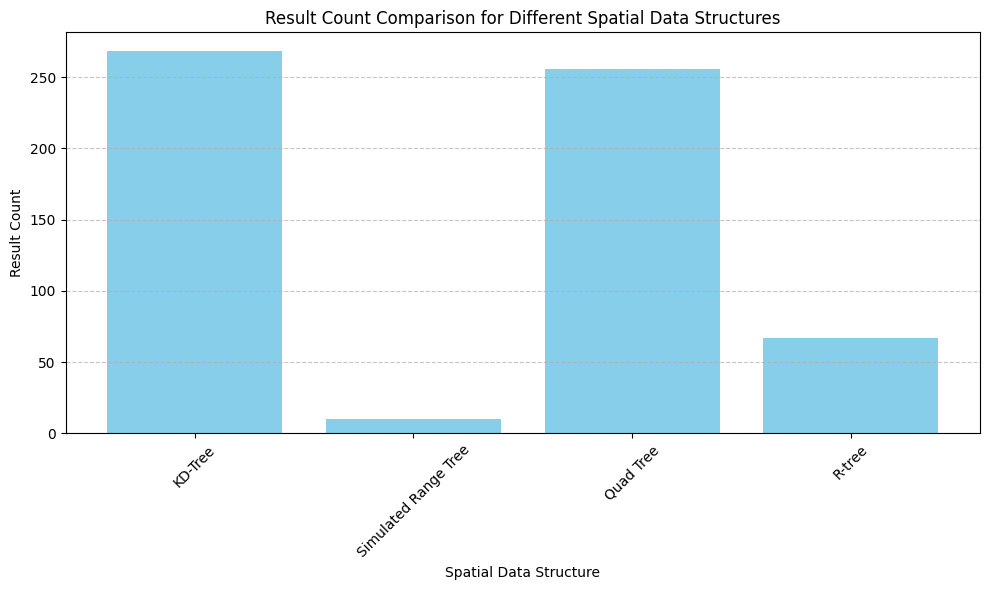

In [29]:
import matplotlib.pyplot as plt

data_structures = ['KD-Tree', 'Simulated Range Tree', 'Quad Tree', 'R-tree']
result_counts = [268, 10, 256, 67]

# Create a bar plot for result counts
plt.figure(figsize=(10, 6))
plt.bar(data_structures, result_counts, color='skyblue')
plt.title('Result Count Comparison for Different Spatial Data Structures')
plt.xlabel('Spatial Data Structure')
plt.ylabel('Result Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
